In [9]:
import kagglehub
import pandas as pd
import numpy as np
import os


try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv' ))
    print('Thursday data confirmed. :)')

except Exception as e:
    print(f'Something went wrong {e}')


data.head()

Thursday data confirmed. :)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [10]:
data.columns = data.columns.str.strip()

print(data.shape)

print(data.dtypes)

(170366, 79)
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object


In [11]:
print(data.isnull().sum())
print('----')
print(data['Label'].value_counts())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64
----
Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64


In [ ]:

from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1'
]

data['Label'] = le.fit_transform(data['Label'])

missing_counts = data.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
print('Columns with missing/ inf value:')
print(missing_counts)


before = len(data)
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)
print(data.shape)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

Columns with missing/ inf value:
Flow Bytes/s    20
dtype: int64
(170231, 79)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33632
           1       0.72      0.79      0.76       273
           2       1.00      0.40      0.57         5
           3       0.46      0.33      0.38       137

    accuracy                           1.00     34047
   macro avg       0.80      0.63      0.68     34047
weighted avg       1.00      1.00      1.00     34047



In [15]:
#  SQL injection (3) is underfitted — not enough data to learn from. The ~8000:1 class imbalance means the model doesn't see enough SQL Injection samples compared to BENIGN to learn effectively. 
#  data to work with.

Fwd IAT Min                0.125546
Flow IAT Min               0.072746
Fwd IAT Std                0.058122
Fwd IAT Mean               0.046312
Init_Win_bytes_backward    0.046188
Flow IAT Std               0.041531
Flow IAT Mean              0.040462
Fwd Packets/s              0.040364
Flow Duration              0.035898
Flow IAT Max               0.029197
dtype: float64


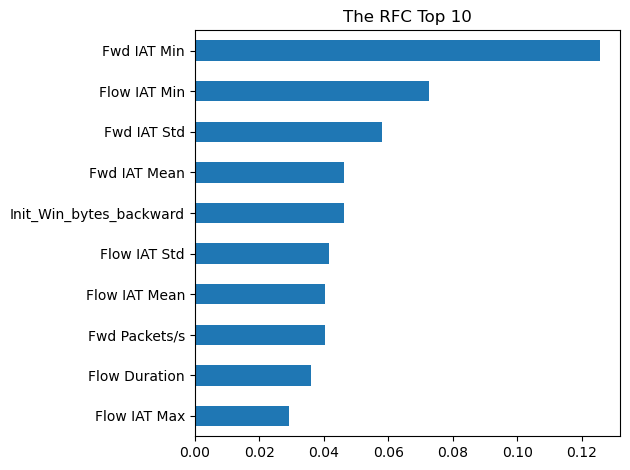

In [16]:
import matplotlib.pyplot as plt

rfc_importance = RandomForestClassifier(n_estimators = 100, random_state=1)
rfc_importance.fit(X,y)

importance = pd.Series(rfc_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).sort_values().plot(kind='barh')
plt.title('The RFC Top 10')
plt.tight_layout()
plt.show()